# DM887 GRPO for Control — Midway PoC (Final)

**Status:** the midway baseline matrix is complete — PPO, SAC, TD3 × CartPole-Swingup, Acrobot-Swingup, CarRacing-v3 (continuous) × 5 seeds = **45 runs / 900 evaluation rows**.

This notebook is the **final, report-facing midway notebook** for the DM887 GRPO project. It is the only notebook that should be referenced from the midway report.

## 2. Notebook Purpose and Reproducibility Map

**Purpose.** This notebook is the single report-facing midway artefact. It explains the project, validates the completed result CSVs, displays the existing figures, and provides cautious interpretation of the numbers. It is **read-only with respect to experiments**: it never trains, never invokes the summarizer, never writes CSVs or PNGs, and never mounts external storage.

**Where the work actually happens.**

| Step | Component | Location |
|------|-----------|----------|
| 1. Vector-control training (PPO/SAC/TD3 on CartPole-Swingup, Acrobot-Swingup) | ObjectRL-driven CLI | [scripts/run_project_objectrl_baseline.py](../scripts/run_project_objectrl_baseline.py) |
| 2. CarRacing CNN training (PPO-CNN/SAC-CNN/TD3-CNN on CarRacing-v3 continuous) | Project-side PyTorch CLI | [scripts/run_carracing_cnn_baseline.py](../scripts/run_carracing_cnn_baseline.py) |
| 3. Aggregation + figure generation | Summarizer CLI | [scripts/summarize_project_baselines.py](../scripts/summarize_project_baselines.py) (`--prefix midway`) |
| 4. Validation, tables, interpretation, figure display | **This notebook** | reads `results/processed/project_baselines/midway_*_eval.csv` and `figures/midway/midway_*.png` |

**Other notebooks under `notebooks/` are archival prototypes** (`*_Codex.ipynb`, `*_ClaudeCode.ipynb`, `*_CopilotCLI.ipynb`, `DM887_Project_GoogleColab.ipynb`). They are kept for history only and are **not required for reproduction**.

**Hard constraints enforced in this notebook.**

- No `subprocess` calls.
- No imports of training modules.
- No file writes (`open(..., 'w')`, `to_csv`, `savefig`, `mkdir`, `pickle.dump`).
- No mounting of Google Drive, no Colab-specific commands.
- All code cells only `read_csv`, `display`, or load existing PNGs via `IPython.display.Image`.

## 3. Official Assignment and Midway Scope

The DM887 project (see `DM887_Project.pdf`, `docs/project.md`) requires evaluating PPO, SAC, and TD3 on:

1. **Continuous Car Racing** (Gymnasium / Farama Box2D, `CarRacing-v3` with `continuous=True`).
2. **CartPole Swingup** (DeepMind Control Suite, `cartpole / swingup`).
3. **Acrobot Swingup** (DeepMind Control Suite, `acrobot / swingup`).

**Midway scope** (this notebook):

- 5 seeds (`0..4`) per (algorithm, environment) combination, shared across algorithms so that paired comparisons remain meaningful.
- Vector-control envs: 20 000 environment steps per run, evaluation every 5 000 steps with 3 episodes.
- CarRacing CNN envs: 10 000 environment steps per run, evaluation every 1 000 steps with 3 episodes.
- **No hyperparameter optimisation** — defaults from the underlying frameworks (ObjectRL for vector envs; the project-side CNN trainers for CarRacing).
- The midway report does not claim convergence; the goal is to establish the pipeline, the artefact layout, and a like-for-like comparison surface for the final report.

## 4. Repository Setup and Path Validation

The next two cells detect `REPO_ROOT` from the notebook's working directory and verify that the directories holding the midway artefacts exist. Nothing is written.

In [1]:
from itertools import product
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def _detect_repo_root() -> Path:
    """Walk upward from the current working directory until we find AGENTS.md and scripts/."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "AGENTS.md").is_file() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate REPO_ROOT from {here}")


REPO_ROOT = _detect_repo_root()
SCRIPTS_DIR = REPO_ROOT / "scripts"
PROCESSED_DIR = REPO_ROOT / "results" / "processed" / "project_baselines"
FIGURES_MIDWAY_DIR = REPO_ROOT / "figures" / "midway"

print(f"REPO_ROOT       : {REPO_ROOT}")
print(f"SCRIPTS_DIR     : {SCRIPTS_DIR}")
print(f"PROCESSED_DIR   : {PROCESSED_DIR}")
print(f"FIGURES_MIDWAY  : {FIGURES_MIDWAY_DIR}")

REPO_ROOT       : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project
SCRIPTS_DIR     : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/scripts
PROCESSED_DIR   : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/results/processed/project_baselines
FIGURES_MIDWAY  : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/figures/midway


In [2]:
# Path validation -- print OK / MISSING for each required directory.
for label, path in [
    ("scripts/",                            SCRIPTS_DIR),
    ("results/processed/project_baselines/", PROCESSED_DIR),
    ("figures/midway/",                     FIGURES_MIDWAY_DIR),
]:
    status = "OK     " if path.is_dir() else "MISSING"
    print(f"{status}  {label:<42}  -> {path}")

OK       scripts/                                    -> /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/scripts
OK       results/processed/project_baselines/        -> /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/results/processed/project_baselines
OK       figures/midway/                             -> /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/figures/midway


## 5. Environment and Algorithm Matrix

| Dimension      | Values |
|----------------|--------|
| Algorithms     | `ppo`, `sac`, `td3` |
| Environments   | `cartpole_swingup`, `acrobot_swingup`, `car_racing_continuous` |
| Seeds          | `0, 1, 2, 3, 4` |
| Total runs     | **45** (3 × 3 × 5) |
| CSV pattern    | `results/processed/project_baselines/midway_{algo}_{env}_seed{seed}_eval.csv` |

Each CSV row records one evaluation episode and uses the columns `algorithm, project_env, seed, train_step, eval_episode, eval_return, wall_time_seconds, status, observation_mode, model_type`.

## 6. Implementation Overview

### 6.1 ObjectRL Vector-Control Baselines

PPO, SAC, and TD3 for `cartpole_swingup` and `acrobot_swingup` are trained through the unmodified ObjectRL package shipped under `external/objectrl/`. The driver script [scripts/run_project_objectrl_baseline.py](../scripts/run_project_objectrl_baseline.py) monkey-patches the `make_env` symbol that `objectrl.experiments.base_experiment` imports so that ObjectRL's `ControlExperiment` constructs its `env` / `eval_env` from [scripts/project_envs.py](../scripts/project_envs.py). Nothing inside `external/objectrl/` is modified — only an in-process name re-binding. The training/evaluation loop, replay buffer, agent updates, and logging are all ObjectRL's.

The DM Control envs are wrapped by `DMCGymAdapter` (see [scripts/project_envs.py](../scripts/project_envs.py)), which flattens DM Control's observation dict into a single `float32` vector and exposes a Gymnasium-style `reset` / `step` API.

### 6.2 CarRacing CNN Baselines

PPO, SAC, and TD3 for `car_racing_continuous` are trained through a project-side CNN baseline implemented in [scripts/carracing_cnn.py](../scripts/carracing_cnn.py) and driven by [scripts/run_carracing_cnn_baseline.py](../scripts/run_carracing_cnn_baseline.py). All three CNN agents — **PPO-CNN, SAC-CNN, TD3-CNN** — are implemented and the full midway 15-run matrix (3 algorithms × 5 seeds) for CarRacing has been completed.

- **Preprocessing** (`CarRacingCNNWrapper`): HWC `uint8` image → CHW `float32` in `[0, 1]`. Output observation space `Box(0, 1, (3, 96, 96), float32)`. No spatial resize, no grayscale, no frame-stack.
- **Trunk** (`CNNFeatureExtractor`): Atari-style 3-conv stack (`8×8 s4`, `4×4 s2`, `3×3 s1`) → flatten → `Linear(4096, 256)` → ReLU.
- **SAC-CNN**: stochastic tanh-Gaussian actor with log-prob correction; twin Q-critics; automatic entropy tuning; Polyak target updates; uint8 image replay buffer.
- **TD3-CNN**: deterministic actor with Gaussian exploration noise; twin Q-critics; target policy smoothing; delayed policy updates (`policy_delay=2`).
- **PPO-CNN**: shared CNN trunk feeding (a) a Gaussian actor head with state-independent `log_std` and (b) a scalar value head; rollout buffer; GAE-λ advantages with normalisation; clipped surrogate policy loss; MSE value loss; entropy bonus; gradient clipping.
- **No hyperparameter tuning** — defaults from the SAC/TD3/PPO literature.

The full CarRacing midway matrix was executed on Google Colab with a CUDA GPU. The resulting evaluation CSVs were copied back into `results/processed/project_baselines/`. The local environment was used only for code, smoke tests, and aggregation. Mounting Google Drive is therefore *not* required to reproduce the analysis in this notebook.

### 6.3 Why CarRacing Is Project-Side CNN

ObjectRL's `external/objectrl/objectrl/agents/base_agent.py` asserts that `observation_space` is a 1-D `Box` and its default actor/critic `arch` callables expect `dim_state: int`. CarRacing-v3 returns `(96, 96, 3)` `uint8` image observations. Adding CNN support would require modifying `external/objectrl/`, which is forbidden by project policy. The CarRacing CNN baseline therefore lives entirely on the project side; the vector envs continue to use ObjectRL unchanged.

## 7. Result File Validation

The next two cells discover every `midway_*_eval.csv` already on disk, cross-check it against the expected matrix, and load all 45 files into a single dataframe (`midway_df`). They write nothing.

In [3]:
EXPECTED_ALGOS = ["ppo", "sac", "td3"]
EXPECTED_ENVS = ["cartpole_swingup", "acrobot_swingup", "car_racing_continuous"]
EXPECTED_SEEDS = [0, 1, 2, 3, 4]
EXPECTED_COMBINATIONS = set(product(EXPECTED_ALGOS, EXPECTED_ENVS, EXPECTED_SEEDS))
EXPECTED_TOTAL_RUNS = len(EXPECTED_COMBINATIONS)

midway_csvs = sorted(PROCESSED_DIR.glob("midway_*_eval.csv"))
print(f"midway CSV files found : {len(midway_csvs)} (expected {EXPECTED_TOTAL_RUNS})")

if midway_csvs:
    midway_df = pd.concat(
        [pd.read_csv(p).assign(source_csv=p.name) for p in midway_csvs],
        ignore_index=True,
    )
else:
    midway_df = pd.DataFrame()

print(f"total rows             : {len(midway_df)} (expected 900)")
if not midway_df.empty:
    print(f"algorithms present     : {sorted(midway_df['algorithm'].unique().tolist())}")
    print(f"environments present   : {sorted(midway_df['project_env'].unique().tolist())}")
    print(f"seeds present          : {sorted(midway_df['seed'].unique().tolist())}")

    have = set(
        midway_df[["algorithm", "project_env", "seed"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    missing = sorted(EXPECTED_COMBINATIONS - have)
    extra = sorted(have - EXPECTED_COMBINATIONS)
    print(f"present combinations   : {len(have & EXPECTED_COMBINATIONS)} / {EXPECTED_TOTAL_RUNS}")
    if missing:
        print(f"MISSING combinations   : {len(missing)}")
        for combo in missing:
            print(f"  - {combo}")
    else:
        print("MISSING combinations   : 0")
    if extra:
        print(f"unexpected combinations: {len(extra)}")

midway CSV files found : 45 (expected 45)
total rows             : 900 (expected 900)
algorithms present     : ['ppo', 'sac', 'td3']
environments present   : ['acrobot_swingup', 'car_racing_continuous', 'cartpole_swingup']
seeds present          : [0, 1, 2, 3, 4]
present combinations   : 45 / 45
MISSING combinations   : 0


In [4]:
# Compact status / coverage table per (algorithm x environment).
if not midway_df.empty:
    status_table = (
        midway_df.groupby(["project_env", "algorithm"])
        .agg(
            n_seeds=("seed", "nunique"),
            n_eval_rows=("eval_return", "size"),
            min_train_step=("train_step", "min"),
            max_train_step=("train_step", "max"),
            statuses=("status", lambda s: ",".join(sorted(set(map(str, s.dropna()))))),
        )
        .reset_index()
        .sort_values(["project_env", "algorithm"])
        .reset_index(drop=True)
    )
    print("Per-(env, algorithm) status:")
    display(status_table)

    print("\nGlobal status value counts:")
    display(
        midway_df["status"].value_counts(dropna=False)
        .rename_axis("status").reset_index(name="n_rows")
    )
else:
    print("midway_df is empty -- no aggregation possible.")

Per-(env, algorithm) status:


,project_env,algorithm,n_seeds,n_eval_rows,min_train_step,max_train_step,statuses
0,acrobot_swingup,ppo,5,75,0,19999,completed
1,acrobot_swingup,sac,5,75,0,19999,completed
2,acrobot_swingup,td3,5,75,0,19999,completed
3,car_racing_continuous,ppo,5,150,1000,10000,completed
4,car_racing_continuous,sac,5,150,1000,10000,completed
5,car_racing_continuous,td3,5,150,1000,10000,completed
6,cartpole_swingup,ppo,5,75,0,19999,completed
7,cartpole_swingup,sac,5,75,0,19999,completed
8,cartpole_swingup,td3,5,75,0,19999,completed



Global status value counts:


,status,n_rows
0,completed,900


## 8. Aggregated Result Tables

For each `(algorithm, environment, seed)` we take the run's last evaluation block (largest `train_step`) and average the per-episode returns at that block. We then aggregate across the 5 seeds into mean / std / min / max of the per-seed final mean return.

**Caveat:** the midway runs are intentionally short. These tables describe the *end-of-budget* policy, not a converged one. Treat them as preliminary indicators (see Section 9).

In [5]:
if not midway_df.empty:
    eval_rows = midway_df[midway_df["eval_return"].notna()].copy()

    # Per-run last train_step.
    last_steps = (
        eval_rows.groupby(["algorithm", "project_env", "seed"])
        ["train_step"].max()
        .reset_index()
    )
    last_steps = last_steps.rename(columns={"train_step": "last_train_step"})
    final_block = eval_rows.merge(
        last_steps,
        left_on=["algorithm", "project_env", "seed", "train_step"],
        right_on=["algorithm", "project_env", "seed", "last_train_step"],
    )

    per_seed_final = (
        final_block.groupby(["algorithm", "project_env", "seed"], as_index=False)
        .agg(
            final_train_step=("train_step", "max"),
            final_mean_eval_return=("eval_return", "mean"),
        )
    )

    summary = (
        per_seed_final.groupby(["project_env", "algorithm"], as_index=False)
        .agg(
            mean_final_return=("final_mean_eval_return", "mean"),
            std_final_return=("final_mean_eval_return", "std"),
            min_final_return=("final_mean_eval_return", "min"),
            max_final_return=("final_mean_eval_return", "max"),
            n_seeds=("seed", "nunique"),
        )
        .sort_values(["project_env", "mean_final_return"], ascending=[True, False])
        .reset_index(drop=True)
    )
    print("Per-run final-return table (one row per (algorithm, env, seed)):")
    display(per_seed_final.sort_values(["project_env", "algorithm", "seed"]).reset_index(drop=True))
    print("\nFinal-block summary by environment x algorithm:")
    display(summary)
else:
    per_seed_final = pd.DataFrame()
    summary = pd.DataFrame()
    print("midway_df is empty -- no aggregation possible.")

Per-run final-return table (one row per (algorithm, env, seed)):


,algorithm,project_env,seed,final_train_step,final_mean_eval_return
0,ppo,acrobot_swingup,0,19999,19.695361
1,ppo,acrobot_swingup,1,19999,4.964566
2,ppo,acrobot_swingup,2,19999,24.871658
3,ppo,acrobot_swingup,3,19999,31.991789
4,ppo,acrobot_swingup,4,19999,0.861994
5,sac,acrobot_swingup,0,19999,0.092263
6,sac,acrobot_swingup,1,19999,0.484407
7,sac,acrobot_swingup,2,19999,13.079141
8,sac,acrobot_swingup,3,19999,0.877993
9,sac,acrobot_swingup,4,19999,0.127930



Final-block summary by environment x algorithm:


,project_env,algorithm,mean_final_return,std_final_return,min_final_return,max_final_return,n_seeds
0,acrobot_swingup,ppo,16.477074,13.208912,0.861994,31.991789,5
1,acrobot_swingup,td3,10.656823,9.526693,0.512053,22.896653,5
2,acrobot_swingup,sac,2.932347,5.681132,0.092263,13.079141,5
3,car_racing_continuous,sac,-25.139777,15.651311,-37.106382,1.898805,5
4,car_racing_continuous,td3,-80.033772,13.654906,-93.635174,-57.042108,5
5,car_racing_continuous,ppo,-91.747155,2.903162,-93.635174,-86.618877,5
6,cartpole_swingup,sac,283.183651,73.752449,192.437419,369.872152,5
7,cartpole_swingup,td3,205.822012,70.615329,152.022924,329.330373,5
8,cartpole_swingup,ppo,86.701853,62.612355,24.767230,182.785105,5


## 9. Result Interpretation

All claims below are conditioned on **the midway training budget** (20 000 steps for vector envs, 10 000 steps for CarRacing) and the **default hyperparameters** of each algorithm. No tuning was performed. Differences should be read as *preliminary pipeline-validation signals*, not as asymptotic comparisons.

### 9.1 Best algorithm per environment based on final evaluation return

Within each environment, algorithms are ranked by `mean_final_return` across the 5 seeds. Ties broken by `std_final_return` (smaller = better).

In [6]:
if not summary.empty:
    ranking = summary.copy()
    ranking["rank"] = (
        ranking.groupby("project_env")["mean_final_return"]
        .rank(ascending=False, method="min").astype(int)
    )
    ranking = ranking.sort_values(
        ["project_env", "rank", "std_final_return"], ascending=[True, True, True]
    ).reset_index(drop=True)
    display(ranking[["project_env", "rank", "algorithm", "mean_final_return", "std_final_return", "n_seeds"]])

    print("\nBest algorithm per environment at midway budget:")
    best = ranking[ranking["rank"] == 1][["project_env", "algorithm", "mean_final_return", "std_final_return"]]
    display(best.reset_index(drop=True))
else:
    print("summary is empty -- no ranking possible.")

,project_env,rank,algorithm,mean_final_return,std_final_return,n_seeds
0,acrobot_swingup,1,ppo,16.477074,13.208912,5
1,acrobot_swingup,2,td3,10.656823,9.526693,5
2,acrobot_swingup,3,sac,2.932347,5.681132,5
3,car_racing_continuous,1,sac,-25.139777,15.651311,5
4,car_racing_continuous,2,td3,-80.033772,13.654906,5
5,car_racing_continuous,3,ppo,-91.747155,2.903162,5
6,cartpole_swingup,1,sac,283.183651,73.752449,5
7,cartpole_swingup,2,td3,205.822012,70.615329,5
8,cartpole_swingup,3,ppo,86.701853,62.612355,5



Best algorithm per environment at midway budget:


,project_env,algorithm,mean_final_return,std_final_return
0,acrobot_swingup,ppo,16.477074,13.208912
1,car_racing_continuous,sac,-25.139777,15.651311
2,cartpole_swingup,sac,283.183651,73.752449


### 9.2 Learning progress from first to final evaluation step

For each run we compute the mean evaluation return at the *first* evaluation block and at the *last* evaluation block, then take the per-seed mean of the delta. A clearly positive `mean_delta` is evidence that learning is happening within the midway budget; a near-zero or negative delta means the budget is too short to see signal.

In [7]:
if not midway_df.empty:
    eval_rows = midway_df[midway_df["eval_return"].notna()].copy()

    # First / last train_step per run.
    bounds = (
        eval_rows.groupby(["algorithm", "project_env", "seed"])["train_step"]
        .agg(first_step="min", last_step="max")
        .reset_index()
    )
    first_block = eval_rows.merge(
        bounds,
        left_on=["algorithm", "project_env", "seed", "train_step"],
        right_on=["algorithm", "project_env", "seed", "first_step"],
    )
    last_block = eval_rows.merge(
        bounds,
        left_on=["algorithm", "project_env", "seed", "train_step"],
        right_on=["algorithm", "project_env", "seed", "last_step"],
    )
    first_per_run = first_block.groupby(
        ["algorithm", "project_env", "seed"], as_index=False
    ).agg(first_mean_eval_return=("eval_return", "mean"))
    last_per_run = last_block.groupby(
        ["algorithm", "project_env", "seed"], as_index=False
    ).agg(final_mean_eval_return=("eval_return", "mean"))
    progress_per_run = first_per_run.merge(
        last_per_run, on=["algorithm", "project_env", "seed"]
    )
    progress_per_run["delta"] = (
        progress_per_run["final_mean_eval_return"] - progress_per_run["first_mean_eval_return"]
    )

    progress = (
        progress_per_run.groupby(["project_env", "algorithm"], as_index=False)
        .agg(
            mean_first=("first_mean_eval_return", "mean"),
            mean_final=("final_mean_eval_return", "mean"),
            mean_delta=("delta", "mean"),
            std_delta=("delta", "std"),
            n_seeds=("seed", "nunique"),
        )
        .sort_values(["project_env", "mean_delta"], ascending=[True, False])
        .reset_index(drop=True)
    )
    print("Mean eval_return at first vs final eval block, plus delta:")
    display(progress)
else:
    progress = pd.DataFrame()
    print("midway_df is empty -- no progress table.")

Mean eval_return at first vs final eval block, plus delta:


,project_env,algorithm,mean_first,mean_final,mean_delta,std_delta,n_seeds
0,acrobot_swingup,ppo,7.524316,16.477074,8.952758,21.318654,5
1,acrobot_swingup,td3,5.677720,10.656823,4.979103,14.351922,5
2,acrobot_swingup,sac,7.379877,2.932347,-4.447530,15.135600,5
3,car_racing_continuous,td3,-84.079557,-80.033772,4.045785,10.083123,5
4,car_racing_continuous,ppo,-93.100288,-91.747155,1.353133,3.213798,5
5,car_racing_continuous,sac,-13.681157,-25.139777,-11.458620,19.113688,5
6,cartpole_swingup,sac,12.382633,283.183651,270.801018,72.725484,5
7,cartpole_swingup,td3,20.316208,205.822012,185.505804,83.345453,5
8,cartpole_swingup,ppo,25.008228,86.701853,61.693625,62.518543,5


### 9.3 Stability across seeds

Within-run stability is approximated by the std of the per-episode `eval_return` at the final evaluation block. Across-seed stability is the std of the per-seed `final_mean_eval_return` (already in the Section 8 summary). Both are reported per `(env, algorithm)`.

In [8]:
if not midway_df.empty:
    eval_rows = midway_df[midway_df["eval_return"].notna()].copy()
    last_steps = (
        eval_rows.groupby(["algorithm", "project_env", "seed"])["train_step"]
        .max().reset_index()
    )
    last_steps = last_steps.rename(columns={"train_step": "last_train_step"})
    final_block = eval_rows.merge(
        last_steps,
        left_on=["algorithm", "project_env", "seed", "train_step"],
        right_on=["algorithm", "project_env", "seed", "last_train_step"],
    )
    within_run = final_block.groupby(
        ["project_env", "algorithm", "seed"], as_index=False
    ).agg(within_run_eval_std=("eval_return", lambda s: s.std(ddof=0)))
    within_run_agg = within_run.groupby(
        ["project_env", "algorithm"], as_index=False
    ).agg(mean_within_run_eval_std=("within_run_eval_std", "mean"))
    if not summary.empty:
        stability = within_run_agg.merge(
            summary[["project_env", "algorithm", "std_final_return", "n_seeds"]],
            on=["project_env", "algorithm"],
        ).sort_values(
            ["project_env", "std_final_return"], ascending=[True, True]
        ).reset_index(drop=True)
    else:
        stability = within_run_agg
    print("Stability summary (lower std = more stable):")
    display(stability)
else:
    print("midway_df is empty -- no stability table.")

Stability summary (lower std = more stable):


,project_env,algorithm,mean_within_run_eval_std,std_final_return,n_seeds
0,acrobot_swingup,sac,3.968623,5.681132,5
1,acrobot_swingup,td3,14.696409,9.526693,5
2,acrobot_swingup,ppo,20.407896,13.208912,5
3,car_racing_continuous,ppo,0.317776,2.903162,5
4,car_racing_continuous,td3,2.134390,13.654906,5
5,car_racing_continuous,sac,6.867185,15.651311,5
6,cartpole_swingup,ppo,3.645664,62.612355,5
7,cartpole_swingup,td3,18.223746,70.615329,5
8,cartpole_swingup,sac,21.501631,73.752449,5


## 10. Plots

The PNGs below were written by [scripts/summarize_project_baselines.py](../scripts/summarize_project_baselines.py) when it was last run with `--prefix midway`. They are loaded here as static images and **not** regenerated in the notebook. Each per-environment figure shows the mean across seeds with a ±1 std band per algorithm.

### 10.1 CartPole Swingup

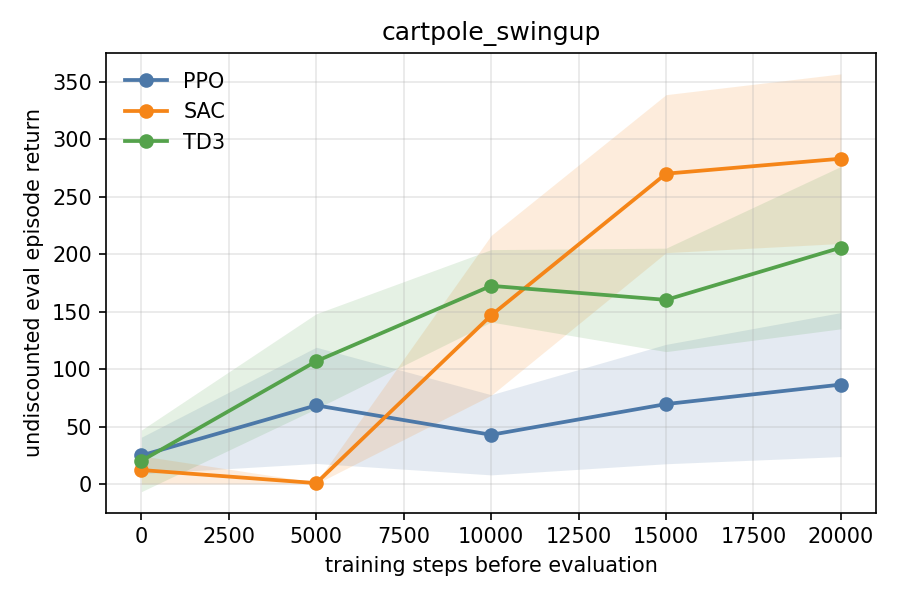

source: figures/midway/midway_cartpole_swingup_baselines.png


In [9]:
_path = FIGURES_MIDWAY_DIR / "midway_cartpole_swingup_baselines.png"
if _path.is_file():
    display(Image(filename=str(_path)))
    print(f"source: {_path.relative_to(REPO_ROOT)}")
else:
    print(f"WARNING: figure missing -- {_path.relative_to(REPO_ROOT)}")

*Interpretation (preliminary).* CartPole-Swingup is the easiest of the three control tasks. At the midway budget we expect off-policy methods (SAC, TD3) to make visible progress within a single short run, while PPO typically needs more environment interaction before its on-policy updates show comparable returns. Cross-check with the ranking and progress tables in Section 9 before drawing any conclusion in the report.

### 10.2 Acrobot Swingup

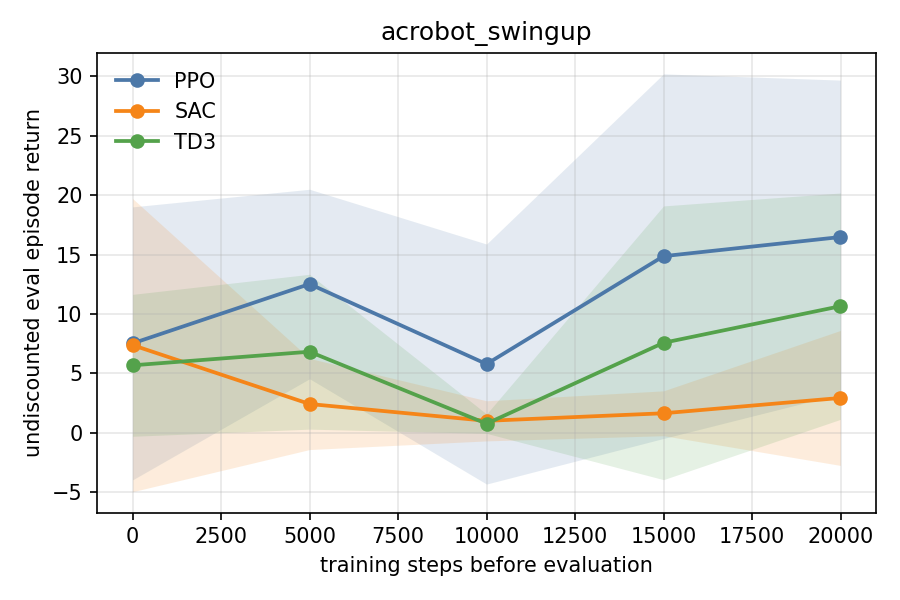

source: figures/midway/midway_acrobot_swingup_baselines.png


In [10]:
_path = FIGURES_MIDWAY_DIR / "midway_acrobot_swingup_baselines.png"
if _path.is_file():
    display(Image(filename=str(_path)))
    print(f"source: {_path.relative_to(REPO_ROOT)}")
else:
    print(f"WARNING: figure missing -- {_path.relative_to(REPO_ROOT)}")

*Interpretation (preliminary).* Acrobot-Swingup is harder than CartPole-Swingup because reward is sparse early on. At 20 000 steps, none of the algorithms is expected to reach asymptotic performance; the curves mainly indicate which algorithm starts to *engage* with the task. Differences should not be over-interpreted.

### 10.3 CarRacing Continuous

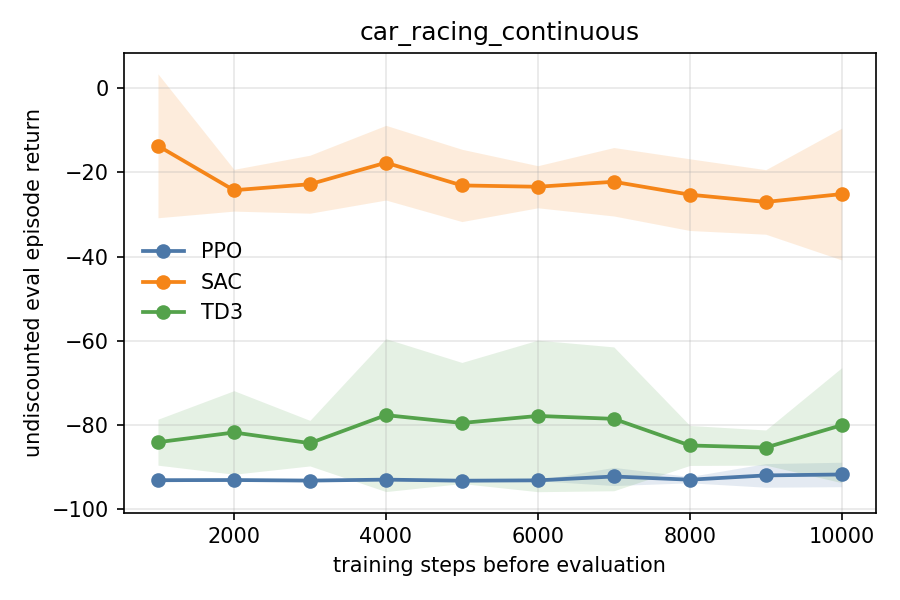

source: figures/midway/midway_car_racing_continuous_baselines.png


In [11]:
_path = FIGURES_MIDWAY_DIR / "midway_car_racing_continuous_baselines.png"
if _path.is_file():
    display(Image(filename=str(_path)))
    print(f"source: {_path.relative_to(REPO_ROOT)}")
else:
    print(f"WARNING: figure missing -- {_path.relative_to(REPO_ROOT)}")

*Interpretation (preliminary).* CarRacing-v3 with raw `(96, 96, 3)` RGB observations is by far the hardest setup in this matrix, and 10 000 environment steps is an extremely small CNN-RL budget. Expect noisy curves and seed-dependent behaviour. The purpose of this figure is to validate that the **PPO-CNN / SAC-CNN / TD3-CNN pipeline runs end-to-end** under the same evaluation protocol as the vector envs, not to compare asymptotic skill.

### 10.4 Combined overview

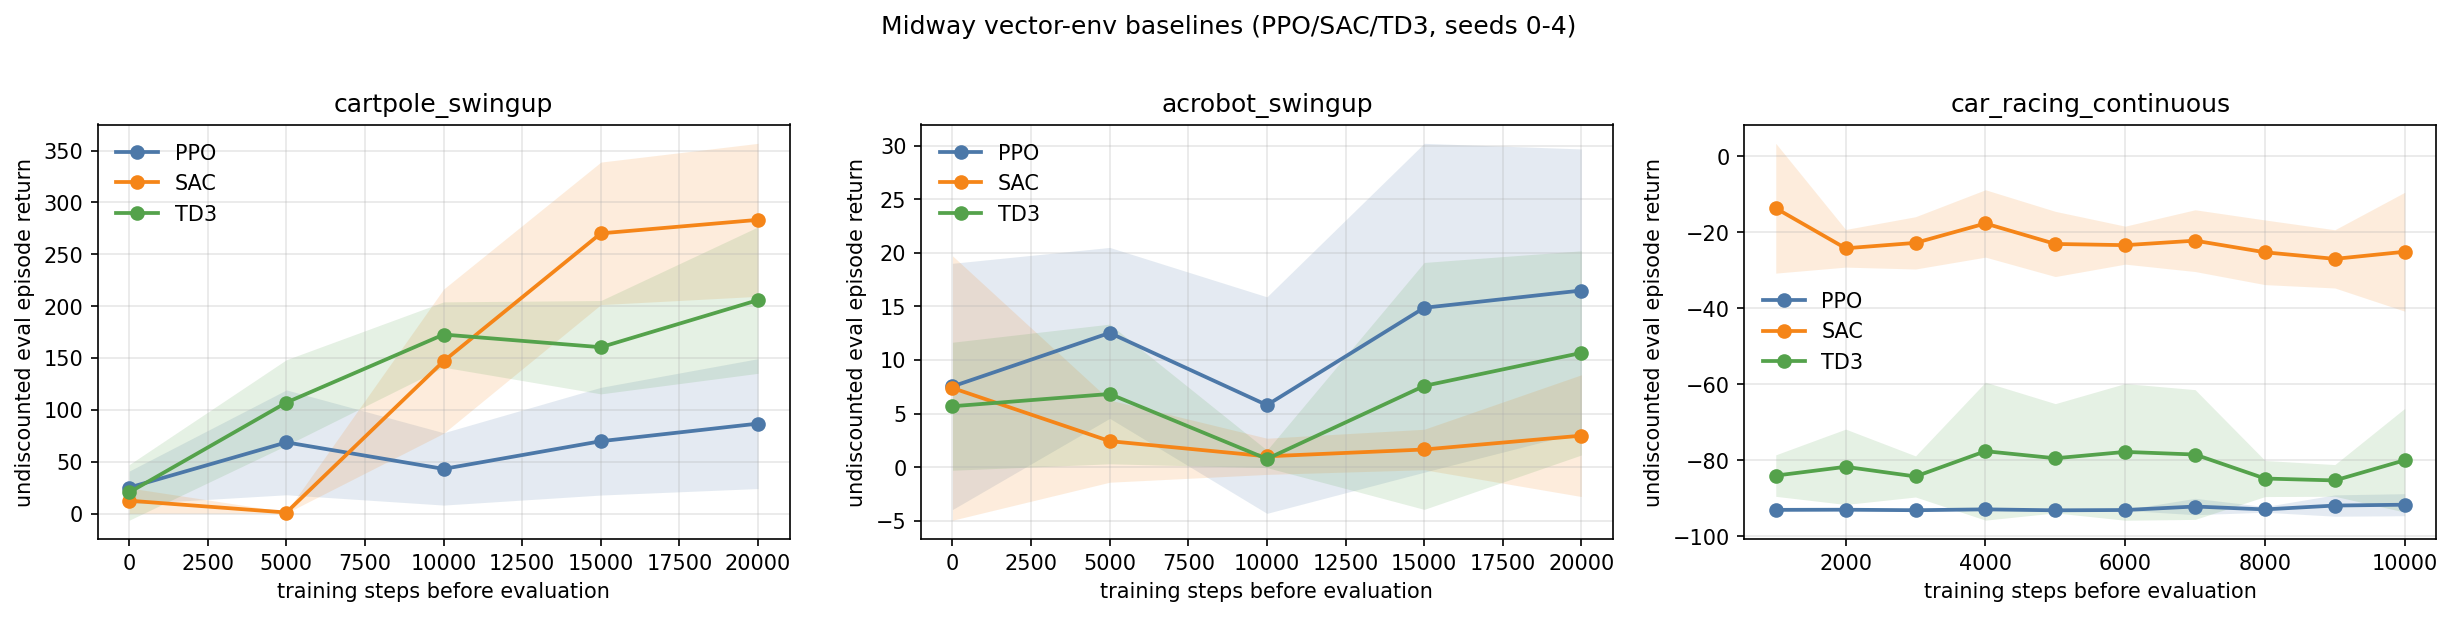

source: figures/midway/midway_vector_env_baselines.png


In [12]:
_path = FIGURES_MIDWAY_DIR / "midway_vector_env_baselines.png"
if _path.is_file():
    display(Image(filename=str(_path)))
    print(f"source: {_path.relative_to(REPO_ROOT)}")
else:
    print(f"WARNING: figure missing -- {_path.relative_to(REPO_ROOT)}")

*Interpretation (preliminary).* The combined overview puts all `(env, algorithm)` curves on a single canvas for a quick visual sanity check. It is a navigation aid, not a primary report figure.

## 11. Midway Conclusion

At the midway training budget, the project has reached the following position:

- The full **3 algorithms × 3 environments × 5 seeds = 45 runs** matrix is on disk and validated by Section 7 (45 CSVs, 900 rows, 0 missing combinations).
- The same evaluation protocol (`undiscounted episode return`, same eval cadence per family, same seed list `0..4`) is used for every cell of the matrix, so the resulting numbers form a like-for-like comparison surface for the final GRPO comparison.
- The vector-control pipeline (PPO/SAC/TD3 via ObjectRL on CartPole-Swingup and Acrobot-Swingup) and the CarRacing CNN pipeline (PPO-CNN/SAC-CNN/TD3-CNN, fully implemented, run on Colab CUDA) are both reproducible from CLI scripts and are not coupled to any notebook.
- These results **validate the pipeline**. Any apparent ordering between PPO, SAC, and TD3 in Sections 9 and 10 should be phrased as preliminary in the report, because the budget is small and no hyperparameter optimisation was performed.

## 12. Report-Ready Notes

**Seeds.** Five seeds per (algorithm, environment) combination, with seeds `0..4` shared across all algorithms so that paired comparisons are meaningful. Each environment's `reset(seed=...)` is called with the run's seed; each algorithm's stochastic components (exploration noise, action sampling, network init) are seeded via `torch.manual_seed(seed)` and `numpy.random.seed(seed)` inside the project-side trainers and via ObjectRL's seed plumbing for the vector envs.

**Evaluation protocol.** During training the agent is paused every `eval_frequency` environment steps and rolled out for `eval_episodes` deterministic episodes against an evaluation env constructed with `seed + 10_000`. We log the *undiscounted* episode return for each evaluation episode. The columns `algorithm, project_env, seed, train_step, eval_episode, eval_return` are the canonical comparison surface; `wall_time_seconds, status, observation_mode, model_type` are bookkeeping.

**No hyperparameter tuning.** All algorithms use the default configurations of their respective implementations (ObjectRL defaults for the vector envs; literature defaults for the CarRacing CNN trainers). This is intentional for the midway: the goal is to establish the pipeline and the artefact layout, not to claim state-of-the-art numbers.

**Limitations of the midway numbers.**

- Step budgets are short (20 000 for vector envs, 10 000 for CarRacing). None of the runs is expected to reach asymptotic performance.
- CarRacing CNN runs use no frame-stack and no grayscale conversion; the 96×96×3 RGB observation is fed to the CNN directly.
- The DM Control adapter (`DMCGymAdapter`) flattens the observation dict into a single vector. This is sufficient for the swingup tasks but discards structure that a downstream final-report version may want to keep.
- Wall-clock numbers are not directly comparable across environments because CarRacing was run on a Colab GPU and vector envs were run on local CPU.

**Interpretation rules used in this notebook.**

- Phrase claims as *"At the midway training budget..."*.
- *"These results validate the pipeline..."*, not *"these results show that algorithm X is best."*
- *"Performance differences should be treated as preliminary..."*.
- Always state *"No hyperparameter optimisation was performed."* alongside any cross-algorithm comparison.

**TODOs intentionally left for manual interpretation in the report:**

- Section 9.1 / 9.2 / 9.3: pick the (env, algorithm) cells where the midway signal is already strong enough to discuss in prose.
- Section 10: which envs are worth re-running with longer budgets in the final report.
- Section 14: whether the GRPO variant should target the same step budgets or be allowed a longer horizon for fairness.

## 13. Optional Reproduction Commands (Documentation Only)

These commands are reproducibility documentation. They are **not** executable cells — do not paste them into the kernel of this notebook. Run them from a shell.

### 13.1 Smoke / debug

```bash
# Vector-env debug (PPO/SAC/TD3 on cartpole_swingup, 1 seed, ~1k steps)
conda run -n RL python scripts/run_project_objectrl_baseline.py \
  --mode debug --algorithm all --env cartpole_swingup --device cpu \
  --time-limit-minutes 5 --allow-batch-run --run

# CarRacing CNN debug (PPO, 1 seed, ~1k steps on CPU)
conda run -n RL python scripts/run_carracing_cnn_baseline.py \
  --algorithm ppo --seed 0 --max-steps 1000 \
  --eval-frequency 500 --eval-episodes 1 --device cpu \
  --time-limit-minutes 5 --run
```

### 13.2 Vector-env midway batch (all algorithms, 5 seeds, CPU)

```bash
conda run -n RL python scripts/run_project_objectrl_baseline.py \
  --mode midway --algorithm all --env cartpole_swingup --device cpu \
  --time-limit-minutes 60 --allow-batch-run --run

conda run -n RL python scripts/run_project_objectrl_baseline.py \
  --mode midway --algorithm all --env acrobot_swingup --device cpu \
  --time-limit-minutes 60 --allow-batch-run --run
```

### 13.3 CarRacing CNN midway batch on Google Colab (CUDA)

Recommended path because the CarRacing CNN trainers are GPU-bound. Run the following inside a Colab notebook with the repo cloned to `/content/DM887_Project`:

```bash
cd /content/DM887_Project
python scripts/run_carracing_cnn_baseline.py \
  --mode midway --algorithm all --device cuda \
  --time-limit-minutes 180 --allow-batch-run --run
```

After the Colab run finishes, copy `results/processed/project_baselines/midway_*_car_racing_continuous_seed*_eval.csv` and `results/raw/project_baselines/midway_*_car_racing_continuous_seed*/` back into the local repo. *Mounting Google Drive is not required for this notebook* — only the CSVs need to be present locally.

### 13.4 Aggregate + replot

```bash
conda run -n RL python scripts/summarize_project_baselines.py --prefix midway
```

This reads every `results/processed/project_baselines/midway_*_eval.csv` and writes the four PNGs consumed by Section 10. **It must be run from a shell, not from this notebook.**

## 14. Next Steps Toward the Final GRPO Project

1. **Implement GRPO** (Group Relative Policy Optimization) on the same three environments using the same evaluation protocol so the final report can sit GRPO numbers next to PPO/SAC/TD3 with no methodology drift.
2. **Lengthen budgets** for the final report (200 000+ steps for vector envs; longer CarRacing runs on GPU). The midway scripts already support a `final` preset; only the time budget needs to be unlocked.
3. **Light hyperparameter sweep** for GRPO (group size, KL/clip coefficients) reusing the same CSV/figure pipeline used here.
4. **CarRacing CNN improvements** if time permits: frame-stack of 4, grayscale conversion, larger replay buffer for SAC/TD3, larger rollout for PPO. These are isolated to [scripts/carracing_cnn.py](../scripts/carracing_cnn.py).
5. **Statistical reporting**: paired bootstrap or rank-based comparisons across the 5 shared seeds, plus learning-curve area-under-the-curve in addition to final return.
6. TODO (manual): write the midway report sections that reference the tables and figures produced above.